In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model


In [ ]:
train_dir = '/content/drive/MyDrive/Pet_Stool_Dataset/train'
test_dir = '/content/drive/MyDrive/Pet_Stool_Dataset/test'

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Pikselleri 0-1 arasına sıkıştırır
    rotation_range=20,       # Rastgele 20 derece sağa/sola çevir
    width_shift_range=0.2,   # Sağa sola kaydır
    height_shift_range=0.2,  # Aşağı yukarı kaydır
    zoom_range=0.15,         # %15 yakınlaştır
    brightness_range=[0.7, 1.13],
    horizontal_flip=True     # Rastgele ayna görüntüsünü al
)
test_datagen = ImageDataGenerator(rescale=1./255) #normalizasyon

In [ ]:
# Generator klasörlere yollayıp fotoğrafları çekiyoruz
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # MobileNet fotoğrafları sadece bu boyutta kabul eder
    batch_size=16,           # Bilgisayar RAM'i şişmesin diye fotoğraflar 16'şarlı paketler halinde gelsin
    class_mode='categorical' # 4 farklı sınıfımız (hastalığımız) olduğunu belirtiyoruz
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)


Found 251 images belonging to 4 classes.
Found 60 images belonging to 4 classes.


In [ ]:
# Hazır beyni (MobileNetV2) indiriyoruz
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
    )
base_model.trainable = False

In [ ]:
# Kendi karar katmanlarımızı ekliyoruz
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(4, activation='softmax')(x)
# Modeli birleştiriyor
model = Model(
    inputs=base_model.input,
    outputs=predictions
    )

In [ ]:
#derliyoruz
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )
print("Model başarıyla derlendi ve eğitime hazır!")

✅ Model başarıyla derlendi ve eğitime hazır!


In [ ]:
# Motoru çalıştırıyoruz
history = model.fit(
    train_generator,          # Eğitim verilerimiz
    epochs=15,                # Tüm fotoğrafların üzerinden kaç kez geçilecek?
    validation_data=test_generator # Her tur sonunda kendini test etmesi
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.2988 - loss: 1.5477 - val_accuracy: 0.4667 - val_loss: 1.1707
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 445ms/step - accuracy: 0.4741 - loss: 1.1607 - val_accuracy: 0.6500 - val_loss: 0.9318
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 422ms/step - accuracy: 0.5777 - loss: 0.9812 - val_accuracy: 0.7333 - val_loss: 0.7966
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 413ms/step - accuracy: 0.6892 - loss: 0.8019 - val_accuracy: 0.7167 - val_loss: 0.7841
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 348ms/step - accuracy: 0.7012 - loss: 0.7526 - val_accuracy: 0.7000 - val_loss: 0.7281
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 444ms/step - accuracy: 0.7410 - loss: 0.6905 - val_accuracy: 0.7500 - val_loss: 0.6096
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 345ms/step - accuracy: 0.7729 - loss: 0.6684 - val_accuracy: 0.7833 - val_loss: 0.5982
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 420ms/step - accuracy: 0.7490 - loss: 0.6459 - val_accuracy: 0.75

Found 60 images belonging to 4 classes.
Model test fotoğraflarını inceliyor, röntgen çekiliyor...
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


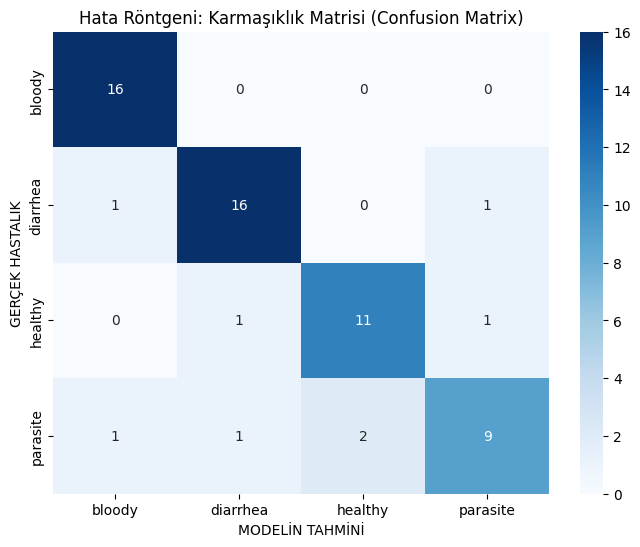


--- HASTALIK BAZINDA DETAYLI KARNE ---
              precision    recall  f1-score   support

      bloody       0.89      1.00      0.94        16
    diarrhea       0.89      0.89      0.89        18
     healthy       0.85      0.85      0.85        13
    parasite       0.82      0.69      0.75        13

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.86      0.87      0.86        60



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Test verisini 'karıştırmadan' (shuffle=False) sırayla tekrar çağırıyoruz
test_generator_eval = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False  # sırayla okunsun.
)

# 2. Modeli sınava sokup tahminlerini alıyoruz
print("Model test fotoğraflarını inceliyor, röntgen çekiliyor...")
tahminler_matrisi = model.predict(test_generator_eval)

# 3. Yüzdelik tahminleri kesin kararlara çeviriyoruz (Örn: %90 ihtimalle Kanlı -> Karar: Kanlı)
y_pred = np.argmax(tahminler_matrisi, axis=1)
y_gercek = test_generator_eval.classes # Klasörlerin gerçek isimleri (Cevap Anahtarı)
sinif_isimleri = list(test_generator_eval.class_indices.keys()) # ['bloody', 'diarrhea', 'healthy', 'parasite']

# 4. Karmaşıklık Matrisini Çizdiriyoruz
cm = confusion_matrix(y_gercek, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sinif_isimleri, yticklabels=sinif_isimleri)
plt.title('Hata Röntgeni: Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('GERÇEK HASTALIK')
plt.xlabel('MODELİN TAHMİNİ')
plt.show()

# 5. Hangi hastalıktan yüzde kaç almış?
print("\n--- HASTALIK BAZINDA DETAYLI KARNE ---")
print(classification_report(y_gercek, y_pred, target_names=sinif_isimleri))

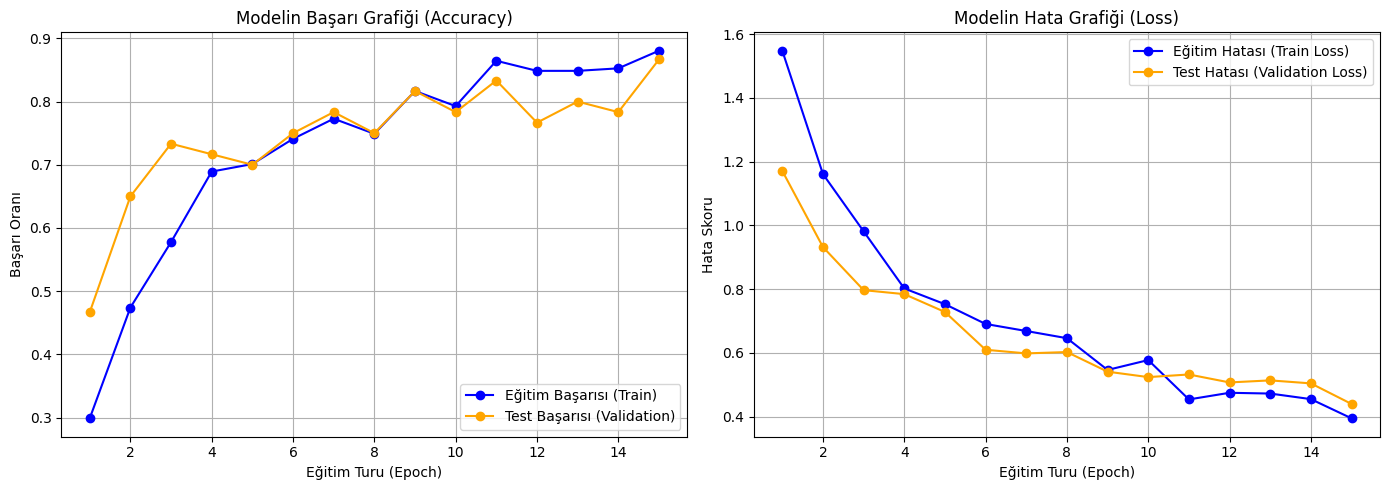

In [ ]:
import matplotlib.pyplot as plt

# Eğitimin geçmişini (history) alıp grafiklere döküyoruz

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# 1. Başarı (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarısı (Train)', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Test Başarısı (Validation)', marker='o', color='orange')
plt.legend(loc='lower right')
plt.title('Modelin Başarı Grafiği (Accuracy)')
plt.xlabel('Eğitim Turu (Epoch)')
plt.ylabel('Başarı Oranı')
plt.grid(True)

# 2. Hata/Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Hatası (Train Loss)', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Test Hatası (Validation Loss)', marker='o', color='orange')
plt.legend(loc='upper right')
plt.title('Modelin Hata Grafiği (Loss)')
plt.xlabel('Eğitim Turu (Epoch)')
plt.ylabel('Hata Skoru')
plt.grid(True)

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
🔎 ScatSpotter Model Hata Analiz Paneli
----------------------------------------
Test Setinde Toplam Hata Sayısı: 8
Hatalı Görüntüler Tek Tek Yükleniyor... (İlk 12 hata gösterilir)



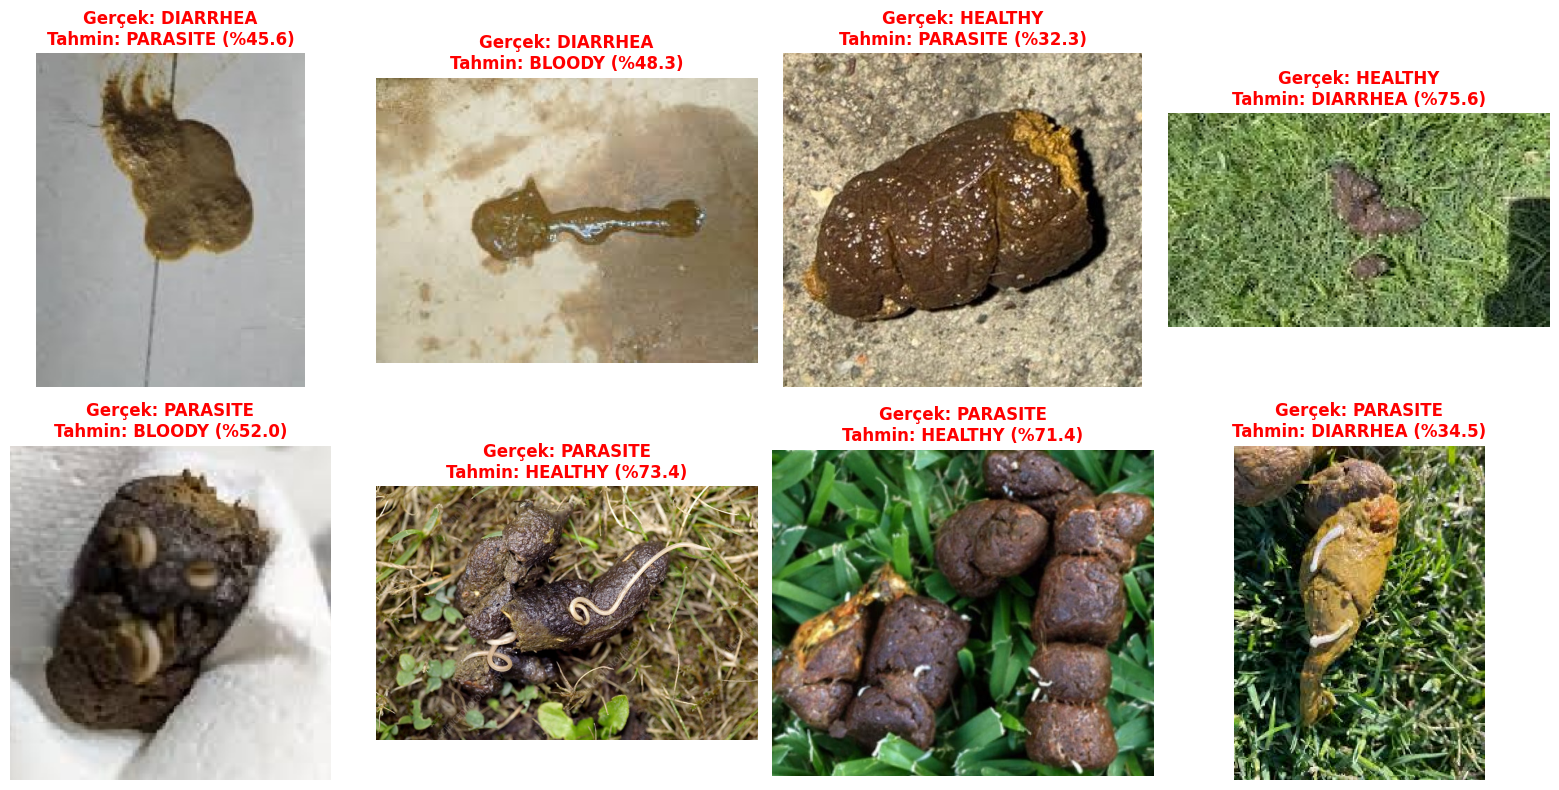


📑 Detaylı Hata Dosya Listesi:
----------------------------------------
Dosya: images13.jpg -> Gerçek: [diarrhea], Tahmin: [parasite]
Dosya: images6.jpg -> Gerçek: [diarrhea], Tahmin: [bloody]
Dosya: WhatsApp Image 2026-03-07 at 15.44.3.jpeg -> Gerçek: [healthy], Tahmin: [parasite]
Dosya: images24.jpg -> Gerçek: [healthy], Tahmin: [diarrhea]
Dosya: 2026-03-20 153823.png -> Gerçek: [parasite], Tahmin: [bloody]
Dosya: Z1800234.jpg -> Gerçek: [parasite], Tahmin: [healthy]
Dosya: d51f51f9bce78ea3b11f54fe0993c23e-scaled.jpg -> Gerçek: [parasite], Tahmin: [healthy]
Dosya: images32.jpg -> Gerçek: [parasite], Tahmin: [diarrhea]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import cv2
import os


# Tahminleri baştan yapıyoruz (IMAGE_1'deki gibi un-shuffled generator)
tahmin_olasiliklar = model.predict(test_generator_eval)
y_pred_indeks = np.argmax(tahmin_olasiliklar, axis=1)
y_gercek_indeks = test_generator_eval.classes
sinif_isimleri = list(test_generator_eval.class_indices.keys())

# 2. Hatalı Tahminleri Tespit Etme (Gerçek != Tahmin)
hatali_indeksler = np.where(y_pred_indeks != y_gercek_indeks)[0]
toplam_hata_sayisi = len(hatali_indeksler)

# Analiz paneli başlığı
print(f"🔎 ScatSpotter Model Hata Analiz Paneli")
print(f"----------------------------------------")
print(f"Test Setinde Toplam Hata Sayısı: {toplam_hata_sayisi}")
print(f"Hatalı Görüntüler Tek Tek Yükleniyor... (İlk 12 hata gösterilir)\n")

# 3. Görüntüleme Mantığı (Görselleri grid şeklinde gösterelim)
if toplam_hata_sayisi == 0:
    print("Mükemmel! Model test setinde hiç hata yapmadı.")
else:
    # Gösterilecek hata sayısını sınırlayalım (Maks 12)
    gosterim_siniri = 12
    hatalar_to_show = hatali_indeksler[:gosterim_siniri]

    # Grid oluşturma (4 kolon, gerektiği kadar satır)
    num_cols = 4
    num_rows = (len(hatalar_to_show) + num_cols - 1) // num_cols
    plt.figure(figsize=(16, 4 * num_rows)) # Genişlik sabit, yükseklik satır sayısına göre artar

    for subplot_idx, veri_idx in enumerate(hatalar_to_show):
        # 3a. Görüntüyü Dosya Yolundan Yükleme
        img_path = test_generator_eval.filepaths[veri_idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV BGR yükler, RGB'ye çeviriyoruz

        # 3b. Bilgileri Derleme
        gercek_etiket = sinif_isimleri[y_gercek_indeks[veri_idx]]
        tahmin_etiket = sinif_isimleri[y_pred_indeks[veri_idx]]
        guven_skoru = tahmin_olasiliklar[veri_idx][y_pred_indeks[veri_idx]] * 100

        # 3c. Çizdirme
        plt.subplot(num_rows, num_cols, subplot_idx + 1)
        plt.imshow(img)
        plt.axis('off') # Eksenleri gizle

        # Başlığı hatalı olduğunu vurgulamak için KIRMIZI yazıyoruz
        plt.title(f"Gerçek: {gercek_etiket.upper()}\n"
                  f"Tahmin: {tahmin_etiket.upper()} (%{guven_skoru:.1f})",
                  color='red', fontsize=12, fontweight='bold')

    plt.tight_layout() # Başlıkların çakışmasını önle
    plt.show() # Grafiği ekrana bas

# 4. Detaylı Metin Listesi (Hangi dosya, neden karışmış)
print(f"\n📑 Detaylı Hata Dosya Listesi:")
print(f"----------------------------------------")
for veri_idx in hatali_indeksler:
    gercek_etiket = sinif_isimleri[y_gercek_indeks[veri_idx]]
    tahmin_etiket = sinif_isimleri[y_pred_indeks[veri_idx]]
    img_path = test_generator_eval.filepaths[veri_idx]
    file_name = os.path.basename(img_path) # Sadece dosya ismini al

    print(f"Dosya: {file_name} -> Gerçek: [{gercek_etiket}], Tahmin: [{tahmin_etiket}]")

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


yeni_foto_yolu = '/content/images.jpg'

# Ön İşleme: Fotoğrafı yapay zekanın "224x224" boyutundaki makinesine sokuyoruz
img = image.load_img(yeni_foto_yolu, target_size=(224, 224))
img_array = image.img_to_array(img)

# Modelin beklediği formata sokma ve Normalizasyon
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

tahminler = model.predict(img_array)

# Sonuçları Yorumlama
sinif_isimleri = list(train_generator.class_indices.keys())
en_yuksek_ihtimal_indeksi = np.argmax(tahminler[0])
teshis = sinif_isimleri[en_yuksek_ihtimal_indeksi]
guven_orani = tahminler[0][en_yuksek_ihtimal_indeksi] * 100

# Sonucu Ekrana Görsel Olarak Basma
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Yapay Zeka Teşhisi: {teshis.upper()} \n(Güven: %{guven_orani:.1f})", color='darkred', fontweight='bold')
plt.axis('off')
plt.show()

# Arka Plandaki İhtimal Dağılımını Görme
print("\n--- MODELİN KAFASINDAKİ DETAYLI İHTİMALLER ---")
for i, sinif in enumerate(sinif_isimleri):
    print(f"{sinif.upper()}: %{tahminler[0][i]*100:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/images.jpg'

In [ ]:
import tensorflow as tf
from google.colab import files

print("1. Modelin ana yedeği (.h5) kaydediliyor...")
model.save('scatspotter_v1.h5')

print("2. Flutter için mobil versiyona (.tflite) dönüştürülüyor...")
# Bu da cep telefonu uygulamanın içine koyacağın hafif versiyon.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('scatspotter_v1.tflite', 'wb') as f:
    f.write(tflite_model)

print("3. Bilgisayarına indirme işlemi başlatılıyor! (Tarayıcı izin isterse onay ver)")
# İki dosyayı da hemen bilgisayarına indiriyoruz.
files.download('scatspotter_v1.h5')
files.download('scatspotter_v1.tflite')

1. Modelin ana yedeği (.h5) kaydediliyor...
2. Flutter için mobil versiyona (.tflite) dönüştürülüyor...
Saved artifact at '/tmp/tmpy5h4b992'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133254139106832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133254139107408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133254139110096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133254139109712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133254139108560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133254139110288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133254139108752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133254139110864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133254139110480: TensorSpec(shape=(), dtype=tf.res

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>